<a href="https://colab.research.google.com/github/luanaoliveira/ebac_data_science_exercises/blob/main/basic_statistics/m13_projeto_supermercado_chile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto: Fundamentos da Descoberta de Dados (EDA) — Supermercado do Chile

Este notebook apresenta uma análise exploratória (EDA) de uma base de produtos de um supermercado do Chile.
O objetivo é aplicar estatística descritiva e visualização de dados para comparar categorias e marcas, com foco em preços e descontos.

**Etapas realizadas:**

1. Cálculo da média e mediana do Preco_Normal por categoria e análise de assimetria (média vs mediana).

2. Cálculo do desvio padrão do Preco_Normal por categoria e interpretação nas categorias mais dispersas.

3. Boxplot do Preco_Normal para a categoria com maior desvio padrão e análise de outliers.

4. Gráfico de barras da média de Desconto por categoria.

5. Treemap interativo (Plotly) por categoria e marca, destacando a média de desconto.

**Base de dados:** title, Marca, Preco_Normal, Preco_Desconto, Preco_Anterior, Desconto, Categoria.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


## 1. Verificação Inicial

In [3]:
df.shape

(1107, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1107 entries, 0 to 1106
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           1107 non-null   object
 1   Marca           1107 non-null   object
 2   Preco_Normal    1107 non-null   int64 
 3   Preco_Desconto  1107 non-null   int64 
 4   Preco_Anterior  1107 non-null   int64 
 5   Desconto        1107 non-null   int64 
 6   Categoria       1107 non-null   object
dtypes: int64(4), object(3)
memory usage: 60.7+ KB


In [5]:
df['Categoria'].unique()

array(['lacteos', 'belleza-y-cuidado-personal', 'congelados', 'frutas',
       'comidas-preparadas', 'verduras', 'instantaneos-y-sopas'],
      dtype=object)

## 2. Estatística Descritiva

### Média, mediana e desvio padrão dos preços (Preco_Normal) por categoria de produto.


In [6]:
media_preco_por_categoria = df.groupby("Categoria")["Preco_Normal"].mean().reset_index().sort_values(by="Preco_Normal", ascending=False)
media_preco_por_categoria

,Categoria,Preco_Normal
1,comidas-preparadas,3095.043478
5,lacteos,2385.219239
2,congelados,2108.042553
0,belleza-y-cuidado-personal,1783.556485
3,frutas,1724.473684
6,verduras,1343.296875
4,instantaneos-y-sopas,765.491228


In [7]:

mediana_preco_por_categoria = df.groupby("Categoria")["Preco_Normal"].median().reset_index().sort_values(by="Preco_Normal", ascending=False)
mediana_preco_por_categoria

,Categoria,Preco_Normal
1,comidas-preparadas,3290.0
0,belleza-y-cuidado-personal,1569.0
2,congelados,1519.0
3,frutas,1195.0
6,verduras,1180.0
5,lacteos,989.0
4,instantaneos-y-sopas,439.0


Identificando as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [8]:
diferenca_media_mediana = (
    df.groupby("Categoria")["Preco_Normal"]
      .agg(media="mean", mediana="median", qtd="count")
      .assign(dif_media_menos_mediana=lambda x: x["media"] - x["mediana"])
      .sort_values("dif_media_menos_mediana", ascending=False)
)

diferenca_media_mediana



,media,mediana,qtd,dif_media_menos_mediana
Categoria,,,,
lacteos,2385.219239,989.0,447,1396.219239
congelados,2108.042553,1519.0,235,589.042553
frutas,1724.473684,1195.0,19,529.473684
instantaneos-y-sopas,765.491228,439.0,57,326.491228
belleza-y-cuidado-personal,1783.556485,1569.0,239,214.556485
verduras,1343.296875,1180.0,64,163.296875
comidas-preparadas,3095.043478,3290.0,46,-194.956522


In [9]:
acima = diferenca_media_mediana.query("dif_media_menos_mediana > 0").index.tolist()
abaixo = diferenca_media_mediana.query("dif_media_menos_mediana < 0").index.tolist()

print("Média ACIMA da mediana (tende a ter outliers à direita):", acima)
print("Média ABAIXO da mediana (tende a ter outliers à esquerda):", abaixo)


Média ACIMA da mediana (tende a ter outliers à direita): ['lacteos', 'congelados', 'frutas', 'instantaneos-y-sopas', 'belleza-y-cuidado-personal', 'verduras']
Média ABAIXO da mediana (tende a ter outliers à esquerda): ['comidas-preparadas']


Ao calcular a média e a mediana do Preco_Normal por categoria, observei que em lacteos, congelados, frutas, instantaneos-y-sopas, belleza-y-cuidado-personal e verduras a média ficou acima da mediana, indicando assimetria à direita (poucos produtos com preços muito altos elevam a média).
Já em comidas-preparadas, a média ficou abaixo da mediana, sugerindo assimetria à esquerda (valores muito baixos puxam a média para baixo).

In [10]:
df.groupby("Categoria")["Preco_Normal"].std().reset_index().sort_values(by="Preco_Normal", ascending=False)

,Categoria,Preco_Normal
5,lacteos,3925.816164
0,belleza-y-cuidado-personal,2210.041719
2,congelados,2111.539896
1,comidas-preparadas,2019.911428
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
6,verduras,1012.699625


**Qual o comportamento da média e mediana nas categorias com maior desvio padrão?**

As categorias com maior desvio padrão são lacteos, belleza-y-cuidado-personal, congelados e comidas-preparadas.
Em geral, nessas categorias a média tende a ficar acima da mediana, o que sugere distribuição assimétrica à direita (presença de produtos muito caros elevando a média e aumentando a variabilidade).
O caso mais evidente é lacteos, onde a diferença entre média e mediana é bem grande, indicando muitos valores extremos (outliers).

## 3. Gráficos

### **Boxplot:** distribuição do Preco_Normal para a categoria que tem o maior desvio padrão.

Text(0.5, 0, 'Preco_Normal')

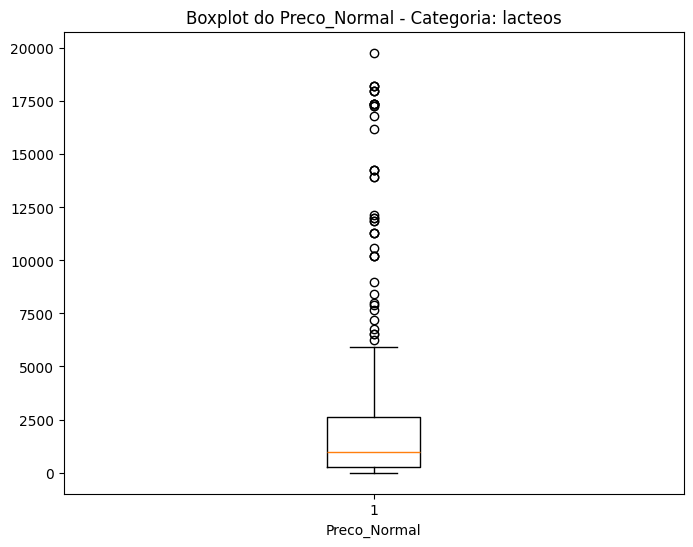

In [11]:
plt.figure(figsize=(8,6))

categoria_maior_desvio = diferenca_media_mediana.index[0]

categoria = df.loc[df['Categoria'] == categoria_maior_desvio]

plt.boxplot(categoria['Preco_Normal'])

plt.title(f"Boxplot do Preco_Normal - Categoria: {categoria_maior_desvio}")
plt.xlabel("Preco_Normal")

No boxplot de lacteos, a maior parte dos preços está concentrada em valores baixos, mas há muitos outliers acima do limite superior, indicando cauda longa à direita. Isso explica o alto desvio padrão e também o fato da média ser bem maior que a mediana nessa categoria.

###**Gráfico de Barras:** média de descontos por categoria.

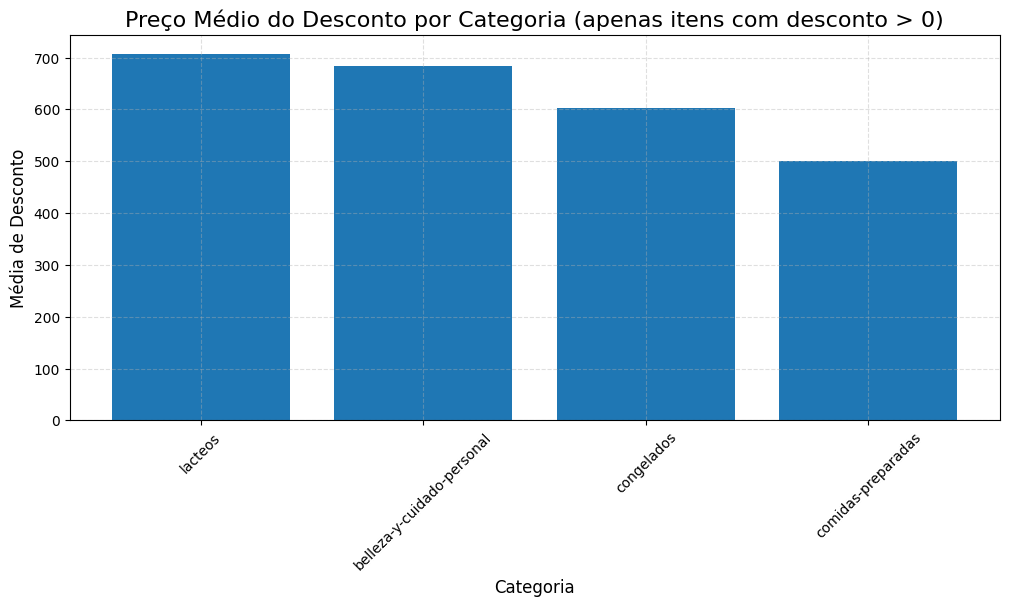

In [12]:
plt.figure(figsize=(12,5))

media_desconto_por_categoria = (
    df.loc[df['Desconto'] > 0]
      .groupby('Categoria')['Desconto']
      .mean()
      .sort_values(ascending=False))


plt.bar(media_desconto_por_categoria.index, media_desconto_por_categoria.values)

plt.title('Preço Médio do Desconto por Categoria (apenas itens com desconto > 0)', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Média de Desconto', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)

plt.show()



No gráfico de barras, observamos que a categoria lacteos possui a maior média de desconto entre os produtos com desconto, seguida por belleza-y-cuidado-personal e congelados. A categoria comidas-preparadas apresenta a menor média de desconto no conjunto filtrado (Desconto > 0), indicando descontos menores quando comparada às demais.

### **Mapa interativo:** agrupando os dados por categoria, marca e trazendo a média de desconto.

In [13]:
media_desconto_por_categoria_marca = (
    df.groupby(['Categoria', 'Marca'])['Desconto']
    .agg(media_desconto='mean', quantidade_produtos='count')
    .reset_index())

fig = px.treemap(media_desconto_por_categoria_marca,
                 path=['Categoria', 'Marca'],
                 values='quantidade_produtos',
                 hover_data={"media_desconto":":.2f", "quantidade_produtos":True},
                 title="Treemap: Categoria → Marca | Cor = média de desconto | Tamanho = quantidade de produtos",
                 color="media_desconto")
fig.show()

No treemap, o tamanho dos blocos representa a quantidade de produtos por categoria e marca, enquanto a cor representa a média de desconto. Assim, conseguimos identificar rapidamente quais marcas têm maior participação em cada categoria (blocos maiores) e quais apresentam descontos médios mais altos (cores mais intensas).